# Proyecto de Ciencias del Comportamiento: Optimización de Email Marketing

### Contexto

El equipo de especialistas en ciencias del comportamiento ha colaborado con un cliente bancario para incrementar la proporción de usuarios finales que abren un email comercial y hacen clic en un botón interno que redirige a una página web de venta.

### Diseño experimental

Se evalúa la efectividad de tres variantes de correos electrónicos:

* **Email control:** Versión estándar sin palancas conductuales (*nudges*).
* **Tratamiento 1:** Correo electrónico codificado con principios de ciencias del comportamiento.
* **Tratamiento 2:** Segunda variante basada en principios de ciencias del comportamiento.

### Objetivos del análisis

* **Evaluación de impacto:** Medir la eficacia y efectividad de los tratamientos frente al grupo control en las métricas de apertura y clics.
* **Análisis de covariables:** Evaluar el efecto de las variables adicionales disponibles en la base de datos sobre el comportamiento de los usuarios.
* **Data storytelling:** Traducir los hallazgos estadísticos en una narrativa clara y comprensible para el cliente.

## Importe de librerías

In [1]:
#Importe de librerías para los análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.proportion import proportions_ztest
import itertools

## Ingesta de datos

In [2]:
#Creación del dataframe
df = pd.read_csv("/Users/david/BeWay/Centro de Excelencia - Datos/Bases de datos/datos_prueba_tecnica.csv", encoding='latin-1', sep=',')

## Exploratory Data Anlysis (EDA)

### Inspección de los datos

In [26]:
# Tipos y salud de los datos
print("Column data types and non-missing values:")
print(df.info())

# Primeras filas del DataFrame
print("\n First five rows of the DataFrame:")
print(df.head())

# Últimas filas del DataFrame
print("\n Last five rows of the DataFrame:")
print(df.tail())

# Estadísticas de todas las columnas
print("\n Statistics of all columns:")
print(df.describe())

Column data types and non-missing values:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   iid             5000 non-null   int64  
 1   grupo           5000 non-null   str    
 2   or              5000 non-null   int64  
 3   ctor            5000 non-null   int64  
 4   sexo            5000 non-null   int64  
 5   edad            5000 non-null   float64
 6   inve            5000 non-null   float64
 7   uso_app         5000 non-null   int64  
 8   tarjeta_debito  5000 non-null   int64  
 9   tipo_tarjeta    5000 non-null   int64  
 10  formacion       5000 non-null   int64  
dtypes: float64(2), int64(8), str(1)
memory usage: 429.8 KB
None

 First five rows of the DataFrame:
   iid  grupo  or  ctor  sexo       edad         inve  uso_app  \
0    1   ctrl   0     0     0  38.296148  51019.88612        1   
1    2  trat1   1     1     1  54.470670  63

### Limpieza y procesamiento de datos

In [3]:
# Convertir id a string
df['iid'] = df['iid'].astype(str)

# Convertir edad a entero
df['edad'] = df['edad'].astype(int)

# Convertir cols a categoría
catcols = ['grupo', 'or', 'ctor', 'sexo', 'uso_app', 'tarjeta_debito', 'tipo_tarjeta', 'formacion']
df[catcols] = df[catcols].astype('category')

# Reconfirmar na's
print("Valores perdidos por columnas:")
print(df.isna().sum())

# Tipos y valores perdidos
print("\n Column data types and non-missing values:")
print(df.info())

# Primeras filas del DataFrame
print("\n First five rows of the DataFrame:")
print(df.head())

# Últimas filas del DataFrame
print("\n Last five rows of the DataFrame:")
print(df.tail())

# Estadísticas para las numéricas
print("\n Statistics of all columns:")
print(df.describe())

Valores perdidos por columnas:
iid               0
grupo             0
or                0
ctor              0
sexo              0
edad              0
inve              0
uso_app           0
tarjeta_debito    0
tipo_tarjeta      0
formacion         0
dtype: int64

 Column data types and non-missing values:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   iid             5000 non-null   str     
 1   grupo           5000 non-null   category
 2   or              5000 non-null   category
 3   ctor            5000 non-null   category
 4   sexo            5000 non-null   category
 5   edad            5000 non-null   int64   
 6   inve            5000 non-null   float64 
 7   uso_app         5000 non-null   category
 8   tarjeta_debito  5000 non-null   category
 9   tipo_tarjeta    5000 non-null   category
 10  formacion       5000 non-null   categor

### Exploración por variables

In [28]:
# Reconfirmar usuarios únicos
print("\n Análisis iid")
print(f"Número de valores únicos (IDs): {df['iid'].nunique()}")


 Análisis iid
Número de valores únicos (IDs): 5000



Tendencia central y dispersión para edad e inversión:
Estadísticas de edad:
 count    5000.000000
mean       46.761000
std        11.152881
min        18.000000
25%        39.000000
50%        47.000000
75%        54.000000
max        70.000000
Name: edad, dtype: float64

Estadísticas de inversión:
 count     5000.000000
mean     49477.863491
std      10913.533755
min      20689.644810
25%      41616.960403
50%      48159.059205
75%      57818.409473
max      82603.697460
Name: inve, dtype: float64


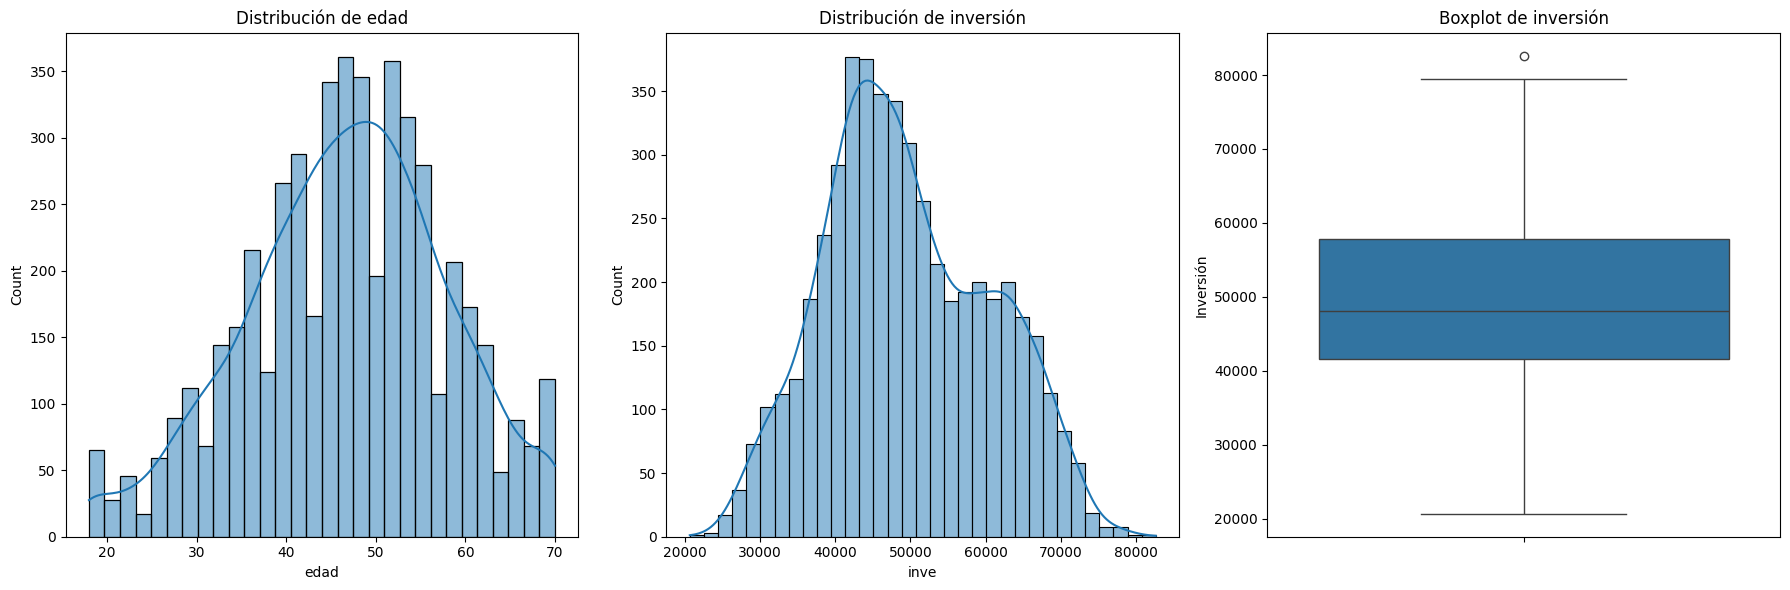

In [29]:
# Medidas de tendencia central y dispersión para edad e ingresos
print("\nTendencia central y dispersión para edad e inversión:")
# Descripción general de las estadísticas
print("Estadísticas de edad:\n", df['edad'].describe())
print("\nEstadísticas de inversión:\n", df['inve'].describe())

# Visualización de la distribución de edad e inversión
# Ajuste del canvas para tres plots
plt.figure(figsize=(18, 6))

# Edad (R1, C1)
plt.subplot(1, 3, 1)  # 3 columnas
sns.histplot(df['edad'], kde=True)
plt.title('Distribución de edad')

# Inversión histograma (R1, C2)
plt.subplot(1, 3, 2) # segunda columna
sns.histplot(df['inve'], kde=True)
plt.title('Distribución de inversión')

# Inversión boxplot (R1, C3)
plt.subplot(1, 3, 3) # tercera columna
sns.boxplot(y=df['inve'])
plt.title('Boxplot de inversión')
plt.ylabel('Inversión')

plt.tight_layout()
plt.show()


Análisis de variables categóricas:


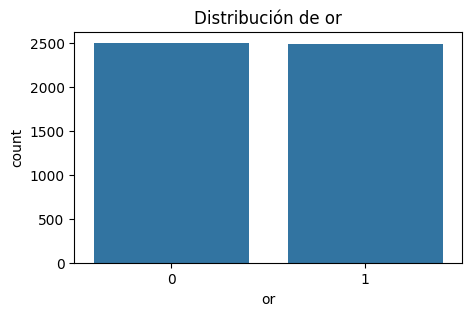

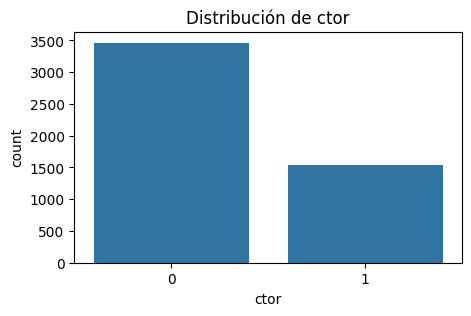

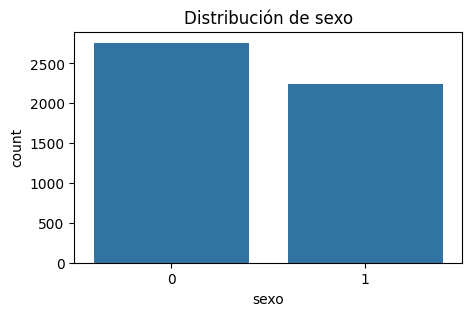

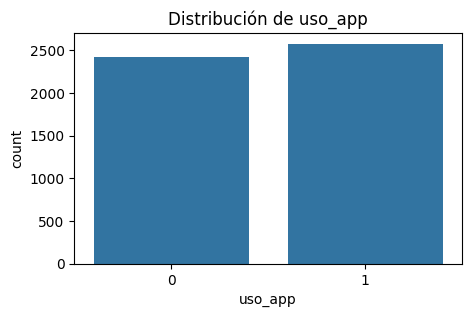

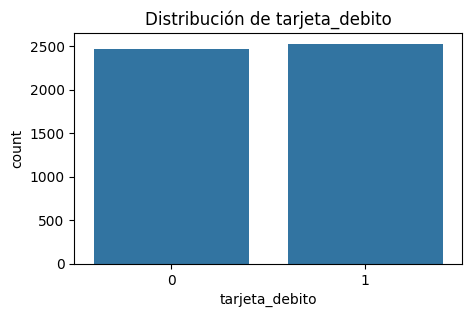

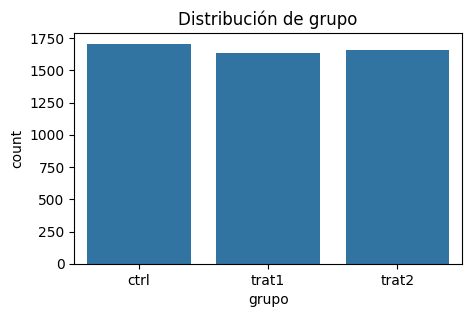

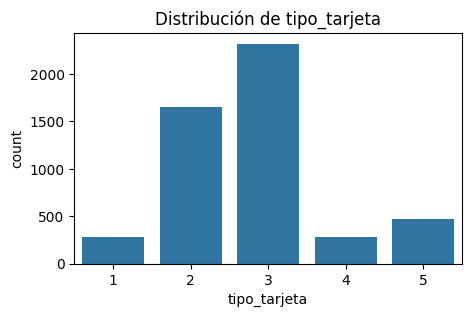

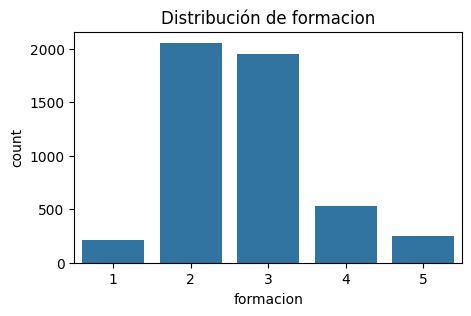

In [30]:
# Análisis de variables categóricas (grupo, sexo, uso_app, tarjeta_debito, tipo_tarjeta)
print("\nAnálisis de variables categóricas:")
for var in ['or', 'ctor', 'sexo', 'uso_app', 'tarjeta_debito','grupo', 'tipo_tarjeta', 'formacion']:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[var])
    plt.title(f'Distribución de {var}')
    plt.show()

### Exploración de covariables

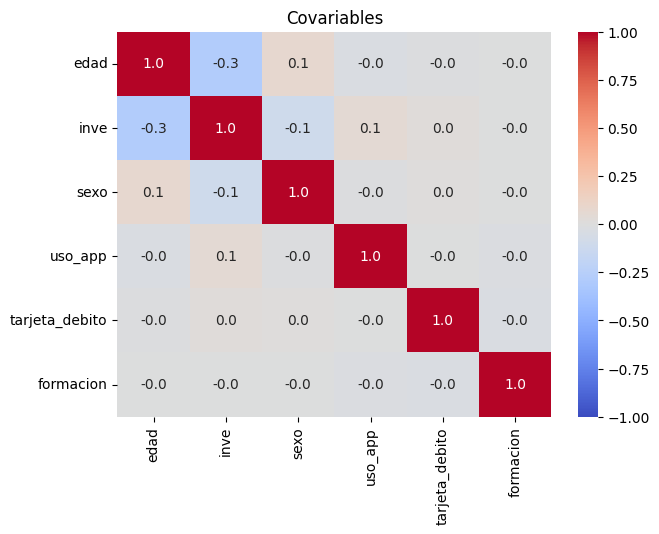

In [31]:
#Definición de covariables
covariables = ['edad', 'inve', 'sexo', 'uso_app', 'tarjeta_debito', 'formacion']

# Matriz de correlación con Spearman
matriz_corr = df[covariables].corr(method='spearman')

# Plotting de la matriz
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, fmt=".1f", cmap="coolwarm", vmin=-1, vmax=1, square=False)
plt.title("Covariables")
plt.show()

### Análisis de razones
#### Definición de funciones de razones
Definición de funciones para calcular las razones para exploración rápida, precisa y reproducible

In [32]:
#Creación de función para el open rate
def open_rate(dataframe, column_names):
    opened = dataframe[dataframe['or'] == 1].groupby(column_names)['iid'].nunique()
    total_users = dataframe.groupby(column_names)['iid'].nunique()        
    open_rate = round(opened / total_users * 100, 1)    
    return open_rate

#Creación de función para el click to open rate
def ctor_rate(dataframe, column_names):
    clicked = dataframe[(dataframe['or'] == 1) & (dataframe['ctor'] == 1)].groupby(column_names)['iid'].nunique()    
    opened = dataframe[dataframe['or'] == 1].groupby(column_names)['iid'].nunique()        
    ctor_rate = round(clicked / opened * 100, 1)
    
    return ctor_rate

def click_rate(dataframe, column_names):
    clicked = dataframe[(dataframe['or'] == 1) & (dataframe['ctor'] == 1)].groupby(column_names)['iid'].nunique()
    total_users = dataframe.groupby(column_names)['iid'].nunique()
    click_rate = round(clicked / total_users * 100, 1)

    return click_rate


#### Cálculo de razones globales

In [33]:
# Cálculo del open rate
print("\nOpen Rate por Grupo de tratamiento") 
resultado_open = open_rate(df, ['grupo'])
open_rate_df = pd.DataFrame(resultado_open)
open_rate_df = pd.DataFrame(open_rate_df.unstack(level=1))
print(open_rate_df)

# Cálculo del click to open rate
print("\nClick to Open Rate por grupo de tratamiento") 
resultado_ctor = ctor_rate(df, ['grupo'])
ctor_rate_df = pd.DataFrame(resultado_ctor)
ctor_rate_df = pd.DataFrame(ctor_rate_df.unstack(level=1))
print(ctor_rate_df)

# Cálculo del click to open rate / total del universo
print("\n Total click rate por grupo de tratamiento") 
resultado_click = click_rate(df, ['grupo'])
click_rate_df = pd.DataFrame(resultado_click)
click_rate_df = pd.DataFrame(click_rate_df.unstack(level=1))
print(click_rate_df)


Open Rate por Grupo de tratamiento
              0
    grupo      
iid ctrl   28.8
    trat1  60.8
    trat2  60.8

Click to Open Rate por grupo de tratamiento
              0
    grupo      
iid ctrl   30.3
    trat1  58.0
    trat2  80.4

 Total click rate por grupo de tratamiento
              0
    grupo      
iid ctrl    8.7
    trat1  35.3
    trat2  48.9


#### Up-lift y multiplicador

In [34]:
# Tasas base (control)
or_control = 28.8
ctor_control = 30.3
tcr_control = 8.7

# Tasas de tratamientos
or_trat1 = 60.8
ctor_trat1 = 58.0
tcr_trat1 = 35.3

or_trat2 = 60.8
ctor_trat2 = 80.4
tcr_trat2 = 48.9

# Cálculos para el tratamiento 1

# Open Rate (OR) - tratamiento 1
or_trat1_veces = or_trat1 / or_control
or_trat1_uplift = ((or_trat1 - or_control) / or_control) * 100
print(f"Open Rate (OR) - tratamiento 1: {or_trat1_veces:.2f} veces, uplift: {or_trat1_uplift:.2f}%")

# Click to open rate (CTOR) -  tratamiento 1
ctor_trat1_veces = ctor_trat1 / ctor_control
ctor_trat1_uplift = ((ctor_trat1 - ctor_control) / ctor_control) * 100
print(f"Click to Open Rate (CTOR) - tratamiento 1: {ctor_trat1_veces:.2f} veces, uplift: {ctor_trat1_uplift:.2f}%")

# Total Click Rate (TCR) - tratamiento 1
tcr_trat1_veces = tcr_trat1 / tcr_control
tcr_trat1_uplift = ((tcr_trat1 - tcr_control) / tcr_control) * 100
print(f"Total Click Rate (TCR) - tratamiento 1: {tcr_trat1_veces:.2f} veces, uplift: {tcr_trat1_uplift:.2f}%\n")


# Cálculos para el tratamiento 2

# Open Rate (OR) - tratamiento 2
or_trat2_veces = or_trat2 / or_control
or_trat2_uplift = ((or_trat2 - or_control) / or_control) * 100
print(f"Open Rate (OR) - tratamiento 2: {or_trat2_veces:.2f} veces, uplift: {or_trat2_uplift:.2f}%")

# Click to open rate (CTOR) - tratamiento 2
ctor_trat2_veces = ctor_trat2 / ctor_control
ctor_trat2_uplift = ((ctor_trat2 - ctor_control) / ctor_control) * 100
print(f"Click to Open Rate (CTOR) - tratamiento 2: {ctor_trat2_veces:.2f} veces, uplift: {ctor_trat2_uplift:.2f}%")

# Total Click Rate (TCR) - tratamiento 2
tcr_trat2_veces = tcr_trat2 / tcr_control
tcr_trat2_uplift = ((tcr_trat2 - tcr_control) / tcr_control) * 100
print(f"Total Click Rate (TCR) - tratamiento 2: {tcr_trat2_veces:.2f} veces, uplift: {tcr_trat2_uplift:.2f}%")

Open Rate (OR) - tratamiento 1: 2.11 veces, uplift: 111.11%
Click to Open Rate (CTOR) - tratamiento 1: 1.91 veces, uplift: 91.42%
Total Click Rate (TCR) - tratamiento 1: 4.06 veces, uplift: 305.75%

Open Rate (OR) - tratamiento 2: 2.11 veces, uplift: 111.11%
Click to Open Rate (CTOR) - tratamiento 2: 2.65 veces, uplift: 165.35%
Total Click Rate (TCR) - tratamiento 2: 5.62 veces, uplift: 462.07%


#### Cálculo de razones específicas - insights

Subsetting

In [35]:
#Subsetting para el análisis de open rate y click to open rate por grupo de tratamiento más efectivo (trat2).
most_effective_group = df[df['grupo'] == 'trat2']
print(most_effective_group.head())

   iid  grupo or ctor sexo  edad         inve uso_app tarjeta_debito  \
2    3  trat2  1    1    1    35  59901.62123       1              0   
6    7  trat2  0    0    1    47  51766.10450       0              1   
8    9  trat2  0    0    1    53  46557.81233       0              0   
9   10  trat2  0    0    1    64  46647.51791       1              1   
11  12  trat2  1    1    0    48  58635.13769       1              1   

   tipo_tarjeta formacion  
2             3         3  
6             2         5  
8             3         5  
9             2         2  
11            3         2  


Exploración sobre el subsetting (most_effective_group)

In [36]:
# Exploración del open rate para most_effective_group (trat2) si tiene tarjeta_debito, tipo_tarjeta, y sexo
print("\nOpen Rate para trat2 con tarjeta_debito, tipo_tarjeta y sexo") 
resultado_open = open_rate(most_effective_group, ['tarjeta_debito', 'tipo_tarjeta', 'sexo'])
open_rate_df = pd.DataFrame(resultado_open)
open_rate_df = pd.DataFrame(open_rate_df.unstack(level=1))
print(open_rate_df)

# Exploración del click to open rate para most effective_group (trat2) si tiene tarjeta_debito, tipo_tarjeta, y sexo
print("\nClick to Open Rate para trat2 con tarjeta_debito, tipo_tarjeta y sexo") 
resultado_ctor = ctor_rate(most_effective_group, ['tarjeta_debito', 'tipo_tarjeta', 'sexo'])
ctor_rate_df = pd.DataFrame(resultado_ctor)
ctor_rate_df = pd.DataFrame(ctor_rate_df.unstack(level=1))
print(ctor_rate_df)


Open Rate para trat2 con tarjeta_debito, tipo_tarjeta y sexo
                      iid                        
tipo_tarjeta            1     2     3     4     5
tarjeta_debito sexo                              
0              0     76.9  44.7  78.6  59.5  59.5
               1     53.8  23.9  57.7  44.4  40.9
1              0     60.0  39.1  81.4  64.0  64.7
               1     45.5  25.9  62.3  45.0  58.1

Click to Open Rate para trat2 con tarjeta_debito, tipo_tarjeta y sexo
                       iid                        
tipo_tarjeta             1     2     3     4     5
tarjeta_debito sexo                               
0              0     100.0  54.2  91.8  77.3  77.3
               1      71.4  33.3  79.1  87.5  66.7
1              0      90.5  71.1  89.3  68.8  87.9
               1      60.0  22.7  70.3  77.8  83.3


#### Transformar variables numéricas a categóricas
Esta parte la hago haga para poder hacer el mismo análisis de la razón por edad y por inversión

In [4]:
#Definición de rangos de edad (bins) y etiquetas (labels) para categorizar la edad en grupos
bins_edad = [18, 25, 35, 50, 65, 71] 
labels_edad = [
    '18 - <25',     
    '25 - <35',   
    '35 - <50', 
    '50 - <65',  
    '≥65'         
]

# pd.cut() con bins y labels definidos manualmente.
most_effective_group['grupo_edad'] = pd.cut(
    most_effective_group['edad'], 
    bins=bins_edad, 
    labels=labels_edad, 
    right=False, # [start, end) - Límite inferior inclusivo, superior exclusivo
    include_lowest=True
)

#Inversión en cuartiles
most_effective_group['cuartil_inve'] = pd.qcut(
    most_effective_group['inve'], 
    q=4, 
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

#Transformar el tipo de variable
most_effective_group['grupo_edad'] = most_effective_group['grupo_edad'].astype('category')
most_effective_group['cuartil_inve'] = most_effective_group['cuartil_inve'].astype('category')

NameError: name 'most_effective_group' is not defined

In [38]:
# Exploración del open rate para most_effective_group (trat2) si tiene tarjeta_debito y grupo etario

print("\nOpen Rate por grupo de tratamiento 2") 
resultado_open = open_rate(most_effective_group, ['tarjeta_debito', 'grupo_edad'])
open_rate_df = pd.DataFrame(resultado_open)
open_rate_df = pd.DataFrame(open_rate_df.unstack(level=1))
print(open_rate_df)

# Exploración del click to open rate para most_effective_group (trat2) si tiene tarjeta_debito y grupo etario
print("\nClick to Open Rate por grupo de tratamiento 2") 
resultado_ctor = ctor_rate(most_effective_group, ['tarjeta_debito', 'grupo_edad'])
ctor_rate_df = pd.DataFrame(resultado_ctor)
ctor_rate_df = pd.DataFrame(ctor_rate_df.unstack(level=1))
print(ctor_rate_df)


Open Rate por grupo de tratamiento 2
                    iid                                 
grupo_edad     18 - <25 25 - <35 35 - <50 50 - <65   ≥65
tarjeta_debito                                          
0                  95.1     90.6     61.8     27.5  15.2
1                  98.7     92.6     61.1     30.0  26.1

Click to Open Rate por grupo de tratamiento 2
                    iid                               
grupo_edad     18 - <25 25 - <35 35 - <50 50 - <65 ≥65
tarjeta_debito                                        
0                 100.0     95.8     77.9     39.3 NaN
1                 100.0     97.5     73.8     43.1 NaN


In [39]:
# Exploración del open rate para most_effective_group si tiene tarjeta_debito y inversión

print("\nOpen Rate por grupo de tratamiento 2 por cuartil de inversión") 
resultado_open = open_rate(most_effective_group, ['cuartil_inve'])
open_rate_df = pd.DataFrame(resultado_open)
open_rate_df = pd.DataFrame(open_rate_df.unstack(level=1))
print(open_rate_df)

# Exploración del click to open rate
print("\nClick to Open Rate por grupo de tratamiento 2 por cuartil de inversión") 
resultado_ctor = ctor_rate(most_effective_group, ['cuartil_inve'])
ctor_rate_df = pd.DataFrame(resultado_ctor)
ctor_rate_df = pd.DataFrame(ctor_rate_df.unstack(level=1))
print(ctor_rate_df)


Open Rate por grupo de tratamiento 2 por cuartil de inversión
                     0
    cuartil_inve      
iid Q1            23.6
    Q2            28.5
    Q3            91.8
    Q4            99.3

Click to Open Rate por grupo de tratamiento 2 por cuartil de inversión
                      0
    cuartil_inve       
iid Q1              NaN
    Q2             27.1
    Q3             96.6
    Q4            100.0


## Análisis inferencial

In [40]:
#Pruebas de normalidad edad
stat, p_valor = shapiro(df['edad'])
print("\nPrueba de normalidad edad:")
print(f"Estadístico W: {stat:.2f}")
print(f"p-valor: {p_valor:.2g}")

#Pruebas de normalidad inversión
stat, p_valor = shapiro(df['inve'])
print("\nPrueba de normalidad inversión:")
print(f"Estadístico W: {stat:.4f}")
print(f"p-valor: {p_valor:.4g}")


Prueba de normalidad edad:
Estadístico W: 0.99
p-valor: 1.6e-16

Prueba de normalidad inversión:
Estadístico W: 0.9849
p-valor: 1.123e-22


### Pruebas específicas
Para todo el DataFrame completo

In [41]:
# Prueba de X2 para el open rate 
tabla_contingencia = pd.crosstab(df['grupo'], df['or'])
print("\nTabla de contingencia para OR:")
print(tabla_contingencia)
print("\nPrueba de Chi-Cuadrado para el open rate:")
chi2, p_val, dof, expected = stats.chi2_contingency(tabla_contingencia)
print(f"Estadístico Chi-cuadrado para OR: {round(chi2, 4)}, p-valor: {round(p_val, 4)}")

# Prueba de Chi-Cuadrado para el click to open rate 
tabla_contingencia = pd.crosstab(df['grupo'], df['ctor'])
print("\nTabla de contingencia para CTOR:")
print(tabla_contingencia)
print("\nPrueba de Chi-Cuadrado para el click to open rate:")
chi2, p_val, dof, expected = stats.chi2_contingency(tabla_contingencia)
print(f"Estadístico Chi-cuadrado para CTOR: {round(chi2, 4)}, p-valor: {round(p_val, 4)}")


Tabla de contingencia para OR:
or        0     1
grupo            
ctrl   1215   492
trat1   642   994
trat2   650  1007

Prueba de Chi-Cuadrado para el open rate:
Estadístico Chi-cuadrado para OR: 458.8426, p-valor: 0.0

Tabla de contingencia para CTOR:
ctor      0    1
grupo           
ctrl   1558  149
trat1  1059  577
trat2   847  810

Prueba de Chi-Cuadrado para el click to open rate:
Estadístico Chi-cuadrado para CTOR: 660.6505, p-valor: 0.0


##### Post-Hoc

In [42]:
# Tabla de contingencia para el open rate
contingencia = pd.crosstab(df['grupo'], df['or'])
grupos = contingencia.index.tolist()
print("Análisis Post-Hoc para open rate")


# Nivel de significancia con corrección de Bonferroni
alfa_original = 0.05

# Cálculo de las combinaciones posibles de a 2 (trat1 vs ctrl, trat2 vs ctrl, trat1 vs trat2)
num_comparaciones = len(list(itertools.combinations(grupos, 2))) 
alfa_bonferroni = alfa_original / num_comparaciones

print(f"Nivel de significancia original: {alfa_original}")
print(f"Nivel de significancia corregido (Bonferroni): {alfa_bonferroni:.4f}\n")

# 3. Comparaciones por pares
pares = list(itertools.combinations(grupos, 2))

for g1, g2 in pares:
    # Extraer los éxitos (or = 1) y el total de observaciones por cada par de grupos
    exitos = [contingencia.loc[g1, 1], contingencia.loc[g2, 1]]
    nobs = [contingencia.loc[g1].sum(), contingencia.loc[g2].sum()]
    
    # Ejecutar prueba Z de dos proporciones
    stat, pval = proportions_ztest(exitos, nobs)
    
    # Evaluar significancia estadística usando el alfa corregido
    significativo = "SÍ" if pval < alfa_bonferroni else "NO"
    
    print(f"Comparación: {g1} vs {g2}")
    print(f"  Estadístico Z: {stat:.4f}")
    print(f"  p-valor: {round(pval,1)}")
    print(f"  ¿Diferencia significativa?: {significativo}\n")

Análisis Post-Hoc para open rate
Nivel de significancia original: 0.05
Nivel de significancia corregido (Bonferroni): 0.0167

Comparación: ctrl vs trat1
  Estadístico Z: -18.5752
  p-valor: 0.0
  ¿Diferencia significativa?: SÍ

Comparación: ctrl vs trat2
  Estadístico Z: -18.6396
  p-valor: 0.0
  ¿Diferencia significativa?: SÍ

Comparación: trat1 vs trat2
  Estadístico Z: -0.0085
  p-valor: 1.0
  ¿Diferencia significativa?: NO



In [6]:
from patsy import dmatrices
# 1. Renombrar la columna 'or' a 'open_rate'
df.rename(columns={'or': 'open_rate'}, inplace=True)

# 2. Asegurar tipos numéricos usando el nuevo nombre
df['open_rate'] = df['open_rate'].astype(int)
df['ctor'] = df['ctor'].astype(int)
df['edad'] = df['edad'].astype(float)
df['inve'] = df['inve'].astype(float)

# 3. Actualizar la fórmula de colinealidad (VIF)
formula_indep = "open_rate ~ C(grupo) + edad + inve + C(sexo) + C(uso_app) + C(tarjeta_debito) + C(tipo_tarjeta) + C(formacion)"

# 4. Ejecutar dmatrices
y_vif, X_vif = dmatrices(formula_indep, df, return_type='dataframe')

## Regresión logística

In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Renombrar la columna problemática
df.rename(columns={'or': 'open_rate'}, inplace=True)

# 2. Asegurar tipos de datos numéricos usando el nuevo nombre
df['open_rate'] = df['open_rate'].astype(int)
df['ctor'] = df['ctor'].astype(int)
df['edad'] = df['edad'].astype(float)
df['inve'] = df['inve'].astype(float)

# ========================================================================
# 3. VERIFICACIÓN DE SUPUESTOS
# ========================================================================

# 3.1 Supuesto 1: Ausencia de Multicolinealidad (VIF)
formula_indep = "open_rate ~ C(grupo) + edad + inve + C(sexo) + C(uso_app) + C(tarjeta_debito) + C(tipo_tarjeta) + C(formacion)"
y_vif, X_vif = dmatrices(formula_indep, df, return_type='dataframe')

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("--- Verificación de Multicolinealidad (VIF) ---")
display(vif_df.round(2))

# 3.2 Supuesto 2: Linealidad de Variables Continuas (Test de Box-Tidwell)
df_bt = df.copy()
if (df_bt['inve'] <= 0).any():
    df_bt['inve'] += 0.01

df_bt['edad_ln'] = df_bt['edad'] * np.log(df_bt['edad'])
df_bt['inve_ln'] = df_bt['inve'] * np.log(df_bt['inve'])

formula_bt = ("open_rate ~ C(grupo, Treatment(reference='ctrl')) + edad + inve + "
              "edad_ln + inve_ln + C(sexo) + C(uso_app) + C(tarjeta_debito) + "
              "C(tipo_tarjeta) + C(formacion)")
modelo_bt = smf.logit(formula_bt, data=df_bt).fit(disp=0)

print("\n--- Verificación de Linealidad (Test Box-Tidwell) ---")
print(modelo_bt.pvalues[['edad_ln', 'inve_ln']])

# ========================================================================
# 4. REGRESIÓN LOGÍSTICA: OPEN RATE
# ========================================================================
formula_or = ("open_rate ~ C(grupo, Treatment(reference='ctrl')) + edad + inve + "
              "C(sexo) + C(uso_app) + C(tarjeta_debito) + C(tipo_tarjeta) + C(formacion)")
modelo_or = smf.logit(formula_or, data=df).fit(disp=0)

print("\n--- Modelo 1: Open Rate ---")
print(modelo_or.summary())

odds_or = pd.DataFrame({
    'Odds_Ratio': np.exp(modelo_or.params),
    'P-valor': modelo_or.pvalues,
    'IC_Inferior_2.5%': np.exp(modelo_or.conf_int()[0]),
    'IC_Superior_97.5%': np.exp(modelo_or.conf_int()[1])
})
display(odds_or.round(3))

# ========================================================================
# 5. REGRESIÓN LOGÍSTICA: CLICK TO OPEN RATE (CTOR)
# ========================================================================
# Filtrar sobre los usuarios que abrieron el email usando el nuevo nombre
df_ctor = df[df['open_rate'] == 1].copy()

formula_ctor = ("ctor ~ C(grupo, Treatment(reference='ctrl')) + edad + inve + "
                "C(sexo) + C(uso_app) + C(tarjeta_debito) + C(tipo_tarjeta) + C(formacion)")
modelo_ctor = smf.logit(formula_ctor, data=df_ctor).fit(disp=0)

print("\n--- Modelo 2: Click to Open Rate (CTOR) ---")
print(modelo_ctor.summary())

odds_ctor = pd.DataFrame({
    'Odds_Ratio': np.exp(modelo_ctor.params),
    'P-valor': modelo_ctor.pvalues,
    'IC_Inferior_2.5%': np.exp(modelo_ctor.conf_int()[0]),
    'IC_Superior_97.5%': np.exp(modelo_ctor.conf_int()[1])
})
display(odds_ctor.round(3))

--- Verificación de Multicolinealidad (VIF) ---


,Variable,VIF
0,Intercept,103.40
1,C(grupo)[T.trat1],1.45
2,C(grupo)[T.trat2],1.65
3,C(sexo)[T.1],1.03
4,C(uso_app)[T.1],1.00
5,C(tarjeta_debito)[T.1],1.00
6,C(tipo_tarjeta)[T.2],4.70
7,C(tipo_tarjeta)[T.3],5.02
8,C(tipo_tarjeta)[T.4],1.89
9,C(tipo_tarjeta)[T.5],2.45



--- Verificación de Linealidad (Test Box-Tidwell) ---
edad_ln     5.027675e-02
inve_ln    6.775237e-125
dtype: float64

--- Modelo 1: Open Rate ---
                           Logit Regression Results                           
Dep. Variable:              open_rate   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4984
Method:                           MLE   Df Model:                           15
Date:                Thu, 02 Jul 2026   Pseudo R-squ.:                  0.1707
Time:                        08:19:05   Log-Likelihood:                -2874.3
converged:                       True   LL-Null:                       -3465.7
Covariance Type:            nonrobust   LLR p-value:                7.664e-243
                                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

,Odds_Ratio,P-valor,IC_Inferior_2.5%,IC_Superior_97.5%
Intercept,0.096,0.000,0.050,0.181
"C(grupo, Treatment(reference='ctrl'))[T.trat1]",2.616,0.000,2.240,3.056
"C(grupo, Treatment(reference='ctrl'))[T.trat2]",1.663,0.000,1.410,1.962
C(sexo)[T.1],0.806,0.001,0.710,0.915
C(uso_app)[T.1],1.010,0.875,0.891,1.145
C(tarjeta_debito)[T.1],1.057,0.386,0.932,1.199
C(tipo_tarjeta)[T.2],0.866,0.323,0.651,1.152
C(tipo_tarjeta)[T.3],1.302,0.064,0.984,1.721
C(tipo_tarjeta)[T.4],0.904,0.594,0.623,1.311
C(tipo_tarjeta)[T.5],1.044,0.799,0.750,1.454



--- Modelo 2: Click to Open Rate (CTOR) ---
                           Logit Regression Results                           
Dep. Variable:                   ctor   No. Observations:                 2493
Model:                          Logit   Df Residuals:                     2477
Method:                           MLE   Df Model:                           15
Date:                Thu, 02 Jul 2026   Pseudo R-squ.:                  0.3273
Time:                        08:19:05   Log-Likelihood:                -1116.8
converged:                       True   LL-Null:                       -1660.2
Covariance Type:            nonrobust   LLR p-value:                3.325e-222
                                                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------
Intercept                                         -4.5300      0.541     -8.377      0.000   

,Odds_Ratio,P-valor,IC_Inferior_2.5%,IC_Superior_97.5%
Intercept,0.011,0.000,0.004,0.031
"C(grupo, Treatment(reference='ctrl'))[T.trat1]",0.641,0.004,0.475,0.865
"C(grupo, Treatment(reference='ctrl'))[T.trat2]",0.766,0.135,0.540,1.086
C(sexo)[T.1],0.814,0.056,0.659,1.006
C(uso_app)[T.1],1.208,0.074,0.982,1.486
C(tarjeta_debito)[T.1],1.089,0.421,0.885,1.341
C(tipo_tarjeta)[T.2],0.682,0.129,0.416,1.118
C(tipo_tarjeta)[T.3],0.912,0.703,0.570,1.461
C(tipo_tarjeta)[T.4],0.764,0.412,0.402,1.452
C(tipo_tarjeta)[T.5],0.923,0.777,0.529,1.610


# Informe de resultados

## Situación

El banco gestiona una base comercial masiva de 500,000 clientes activos en sus plataformas digitales. 
Al ser una población con perfiles transaccionales y demográficos heterogéneos, no todos los segmentos presentan los mismos niveles de conversión ante las campañas de mercadeo tradicionales.

## Complicación

El correo electrónico registra un desempeño bajo en la interacción con los usuarios. La mayoría de los clientes no abre el correo electrónico (28.8%) y, entre quienes lo abren, la proporción que interactúa con el botón de llamado a la acción es baja (30.3%). 
Esto se traduce en una tasa de clic final (Total Click Rate sobre todos los usuarios) del 8.7%, lo que limita la activación de los productos financieros y reduce la eficiencia del canal digital.

## Solución

Para evaluar alternativas de mejora, se diseño e implementó un experimento con una aleatoria de 5,000 individuos; y probaron dos variantes de correo electrónico basadas en Ciencias del Comportamiento (nudges) frente al grupo de control.

* **Tratamiento 1 (trat1):** email con nudge 1.
* **Tratamiento 2 (trat2):** email con nudge 2.

## Resultados

### Desempeño global del embudo Test 1

La prueba X² reveló que **sí existen diferencias significativas** entre las 3 condiciones (control, tratamiento 1 y tratamiento 2) en las métricas del embudo: OR (X² = 458.8, p < 0.05) y CTOR (X² = 660.6, p < 0.05).

Un análisis post hoc mediante pruebas Z de proporciones por pares **reveló diferencias significativas en el open rate entre el grupo control y el tratamiento 1** (Z = -18.5, p < 0.0167) **y entre el grupo control y el tratamiento 2** (Z = -18.6, p < 0.0167), utilizando un nivel de significancia ajustado por Bonferroni de 0.0167 para comparaciones múltiples.

Particularmente:

* **Open Rate (OR):** tanto el tratamiento 1 como el tratamiento 2 alcanzaron una tasa de  apertura de **60.8%**, duplicando el 28.8% del control (**2.11 veces más** y un **uplift del 111.11%**).

* **Click-To-Open Rate (CTOR):** una vez abierto el correo, el tratamiento 2 registró una tasa de cliqueo del **80.4%** frente al 58.0% del Tratamiento 1 y el 30.3% del Control(**2.65 veces** más respecto al control y un **uplift del 165.35%**, igualmente).

* **Total Click Rate (TCR):** En la conversión final sobre el total de la muestra, el Tratamiento 2 consolidó una tasa del **48.9%**, lo que equivale a **5.62 veces** la tasa del Control y un **uplift del 462.07%**

Los modelos de regresión logística revelaron que sí existen diferencias significativas al incorporar los predictores en las métricas del embudo: Open Rate (LLR p-value = 7.66e-243, Pseudo R² = 0.1707) y CTOR (LLR p-value = 3.33e-222, Pseudo R² = 0.3273).

| Métrica | Grupo Control | Tratamiento 1 (Multiplicador / Uplift) | Tratamiento 2 (Multiplicador / Uplift) |
| --- | --- | --- | --- |
| **Open Rate** | 28.8% | 2.11x / +111.11% | **2.11x / +111.11%** |
| **CTOR** | 30.3% | 1.91x / +91.42% | **2.65x / +165.35%** |
| **Total Click Rate** | 8.7% | 4.06x / +305.75% | **5.62x / +462.07%** |

### Desempeño para el tratamiento 2

El análisis de las covariables identificó variaciones en la respuesta al tratamiento 2:

* **Cuartil de inversión:** El Open Rate directamente proporcional a los ingresos. Por ejemplo, es del 23.6% en el cuartil inferior (Q1) y se eleva al **99.3%** en el cuartil superior (**Q4**), donde en el CTOR alcanza el **100%**.

* **Grupos etáreos:** Por el contrario, el Open Rate es inversamente proporcional a la edad de los clientes. Los clientes de 18 a <25 años presentan un Open Rate del 95.1% (que sube a **98.7%** con tarjeta de débito) y un CTOR del **100.0%**. Las tasas decrecen con la edad, registrando un Open Rate de entre 15.2% y 26.1% en el segmento >65 años.

* **Sexo producto:** Las mujeres  sin tarjeta de débito y con **Tipo de Tarjeta 3** registran un Open Rate del 81.4% y un CTOR del **91.8%**. Por su parte, los hombres con tarjeta de débito y tarjeta tipo 2 presentan un CTOR del 22.7%.

## Recomendaciones para el negocio

1. **Sustitución del control:** reemplazar la plantilla tradicional por la del tratamiento 2 para el despliegue en la base restante de 495,000 clientes.
2. **Segmentación del envío:** priorizar el uso automatizado del tratamiento 2 en clientes de los cuartiles superiores de inversión (Q3 y Q4) y aquellos entre los 18 y 34 años. debido a sus tasas de respuesta.
3. **Desarrollar nuevos experimentos:** pobar nuevas intervenciones con los segmentos de menor desempeño y evaluar la efectividad de otros canales.


### Desempeño global del embudo Test 2

El análisis de los coeficientes del modelo **reveló diferencias significativas en el open rate entre el grupo control y el tratamiento 1** (z = 12.14, p < 0.05) **y entre el grupo control y el tratamiento 2** (z = 6.03, p < 0.05). En contraste, para el Click-To-Open Rate (CTOR), solo se observaron diferencias significativas entre el grupo control y el tratamiento 1 (z = -2.91, p < 0.05), mientras que el tratamiento 2 no mostró un efecto estadísticamente significativo frente a la línea base (z = -1.50, p = 0.135).

Particularmente:

Open Rate (OR): Tanto el tratamiento 1 como el tratamiento 2 incrementan significativamente la probabilidad de apertura frente al control, siendo el tratamiento 1 el de mayor impacto (coef = 0.9618 frente a 0.5087). A nivel de covariables, el perfil del usuario afecta el indicador: la edad (coef = -0.0274, p < 0.05) y el sexo 1 (coef = -0.2153, p < 0.05) reducen significativamente el OR, mientras que el nivel de inversión muestra un efecto positivo (coef = 6.65e-05, p < 0.05). Las variables de uso de la app y posesión de tarjeta de débito carecen de impacto estadístico.

Click-To-Open Rate (CTOR): Al segmentar la muestra por los usuarios que efectivamente abrieron el correo, el tratamiento 1 disminuye significativamente la probabilidad de hacer clic en comparación con el control (coef = -0.4449), mientras que el tratamiento 2 no genera un cambio estadístico (p = 0.135). La tendencia de las variables continuas se mantiene idéntica al modelo de apertura, registrando efectos significativos negativos para la edad (coef = -0.0275, p < 0.05) y positivos para el nivel de inversión (coef = 0.0001, p < 0.05). El resto de variables de control (sexo, uso de app, tipo de tarjeta y nivel de formación) no resultaron significativas en esta etapa del embudo.